# **🌍 ESG & Financial Performance**

The goal is to build a multi-regression model that predicts ESG score of a company based on features

## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.multioutput import MultiOutputRegressor, RegressorChain
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              AdaBoostRegressor, StackingRegressor)
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')
print("Libraries successfully downloaded")

Libraries successfully downloaded


## **Data Exploration**

In [3]:
data = pd.read_csv(r"C:\Projects_ML\ESG-Report-Analyzer\ESG-Report-Analyzer-NLP\data\raw\kaggle\company_esg_financial_dataset.csv")

In [4]:
data.head()

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


In [5]:
data.shape

(11000, 16)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: float64(11), int64(

In [7]:
#check for missing values
for col in data.columns:
  if (data[col].isna().sum()) > 0:
    print(f"The {col} column has {data[col].isna().sum()} missing values")

The GrowthRate column has 1000 missing values


In [8]:
#further investigation of the `GrowthRate Column`
print(f"Data type of the GrowthRate Column is: {data['GrowthRate'].dtypes}")
print(f"Number of unique values of the GrowthRate Column are: {data['GrowthRate'].nunique()}")
print(f"Values in the GrowthRate Column: {data['GrowthRate'][:10]}")

Data type of the GrowthRate Column is: float64
Number of unique values of the GrowthRate Column are: 562
Values in the GrowthRate Column: 0     NaN
1     3.2
2    19.2
3    -1.1
4    -0.7
5     2.3
6     6.5
7    -1.8
8     7.3
9     7.9
Name: GrowthRate, dtype: float64


**Since the `GrowthRate` column is a numeric column, I will be filling the missing values with the median. Median would be the best approach since we would mostly likely be dealing with an outlier in the data.**

In [9]:
#check for duplicates
print(data.duplicated().sum())

0


In [10]:
#statistical summary
data.describe().T

,count,mean,std,min,25%,50%,75%,max
CompanyID,11000.0,5.005000e+02,2.886881e+02,1.0,250.750,500.50,750.250,1.000000e+03
Year,11000.0,2.020000e+03,3.162421e+00,2015.0,2017.000,2020.00,2023.000,2.025000e+03
Revenue,11000.0,4.670851e+03,9.969954e+03,35.9,938.775,1902.30,4342.625,1.808104e+05
ProfitMargin,11000.0,1.090045e+01,8.758711e+00,-20.0,5.300,10.50,16.300,5.000000e+01
MarketCap,11000.0,1.338062e+04,3.992287e+04,1.8,1098.525,3096.45,9995.500,8.652717e+05
GrowthRate,10000.0,4.830370e+00,9.424787e+00,-36.0,-1.325,4.90,11.000,3.800000e+01
ESG_Overall,11000.0,5.461527e+01,1.589394e+01,6.3,44.100,54.60,65.600,9.880000e+01
ESG_Environmental,11000.0,5.641699e+01,2.676723e+01,0.0,34.700,55.60,79.000,1.000000e+02
ESG_Social,11000.0,5.566058e+01,2.335615e+01,0.0,37.600,55.15,73.800,1.000000e+02
ESG_Governance,11000.0,5.176765e+01,2.532337e+01,0.0,30.775,52.10,73.000,1.000000e+02


In [11]:
#counting the number of numeric and categorical columns present
num_count, cat_count = 0, 0
for col in data.columns:
  if data[col].dtype != "object":
    num_count += 1
  else:
    cat_count += 1
print(f"Number of numeric columns: {num_count}")
print(f"Number of categorical columns: {cat_count}")

Number of numeric columns: 13
Number of categorical columns: 3


In [12]:
#fill up the missing values in the GrowthRate Column
data['GrowthRate'].fillna(data['GrowthRate'].median(), inplace=True)

#checking the number of missing values in the newly filled column
print(f"Number of missing values: {data["GrowthRate"].isna().sum()}")

Number of missing values: 0


In [13]:
#checking the unique values in the `Year` column
data["Year"].unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

In [14]:
#checking the unique values in `region` column
data["Region"].unique()

array(['Latin America', 'Asia', 'Africa', 'Middle East', 'Oceania',
       'Europe', 'North America'], dtype=object)

In [15]:
#checking the unique values in `Industry` column
data["Industry"].unique()

array(['Retail', 'Transportation', 'Technology', 'Finance', 'Healthcare',
       'Energy', 'Consumer Goods', 'Utilities', 'Manufacturing'],
      dtype=object)

In [16]:
#checking the unique values in the `CompanyName` column
data["CompanyName"].unique()[:10]

array(['Company_1', 'Company_2', 'Company_3', 'Company_4', 'Company_5',
       'Company_6', 'Company_7', 'Company_8', 'Company_9', 'Company_10'],
      dtype=object)

From the various analysis of individual columns above, it is discovered that:
1. The `CompanyName` holds no potential value as they are just generic names or rather placeholders. This column can be dropped when moving ahead with predictive analysis.

2. Future data visualizations can be based or streamlined based on `Year`, `Industry` and `Region`. Making it easier to spot trends in the dataset based on timeline and industry based trends.

## **Data Visualization**
Visualizing columns in our dataset to find out patterns and trends in our dataset.

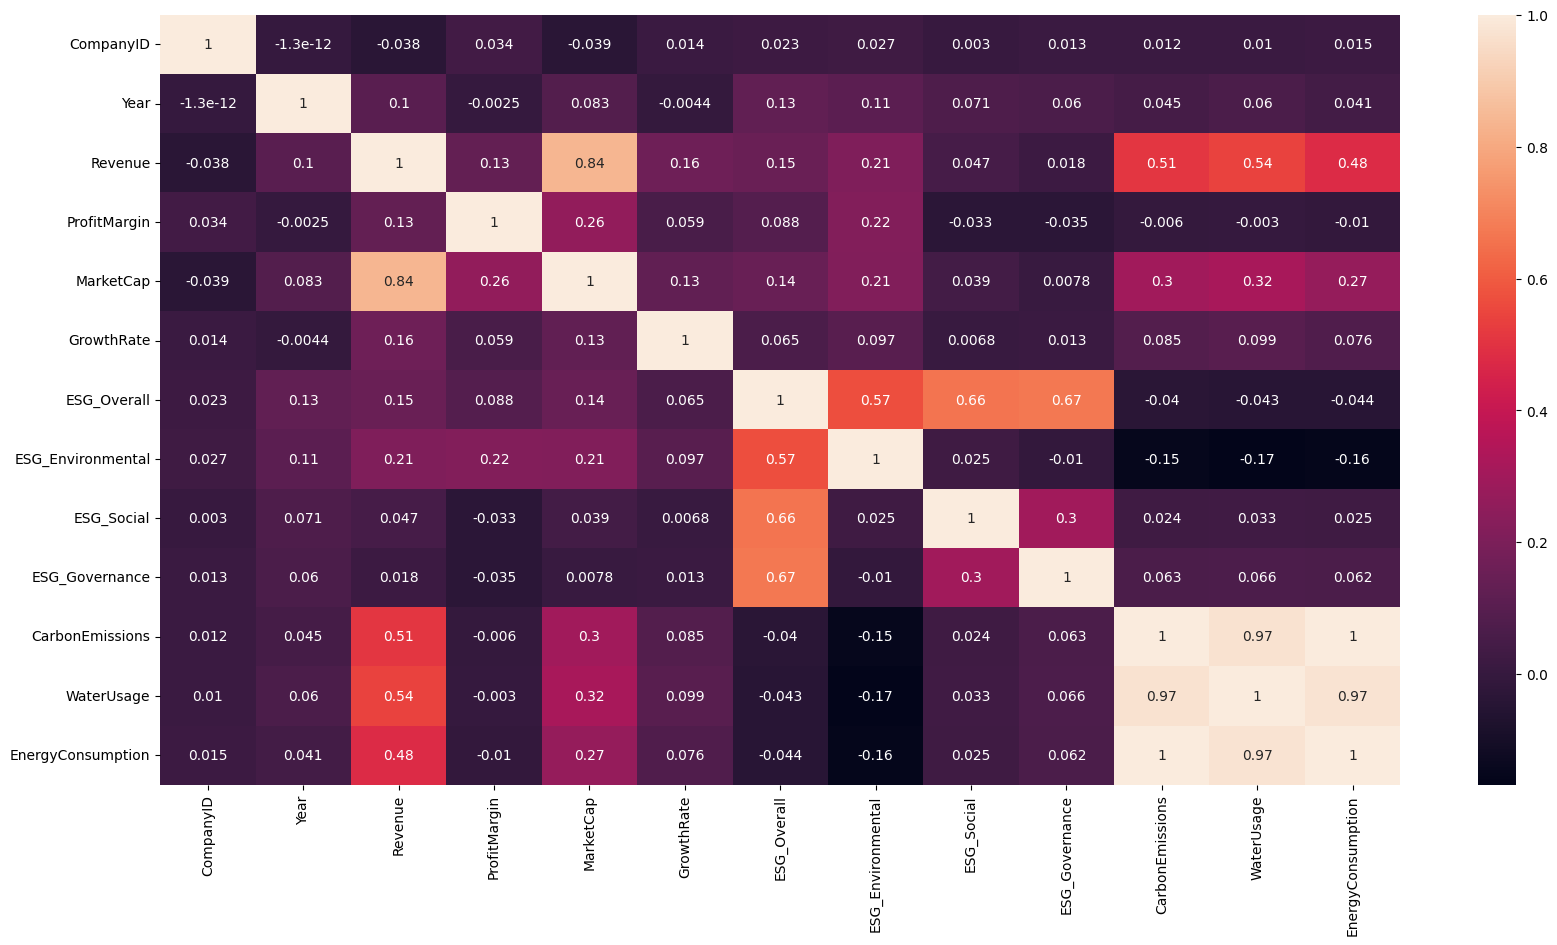

In [17]:
#checking the correlation between columnsin the dataset
plt.figure(figsize=(20,10))
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show();

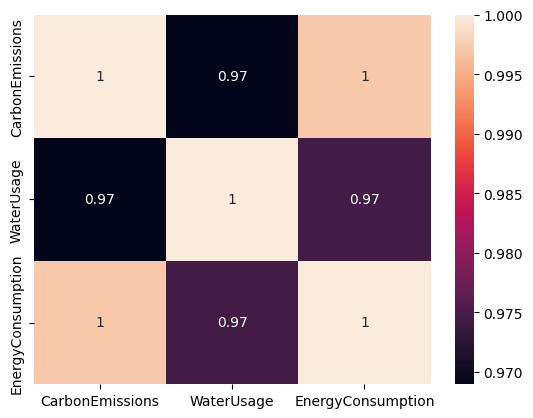

In [18]:
#further investigation on the correlation between CarbonEmissions, WaterUsage and EnergyConsumption
sns.heatmap(data[["CarbonEmissions", "WaterUsage", "EnergyConsumption"]].corr(numeric_only=True),
            annot = True)
plt.show();

These three variables - `CarbonEmissions`, `WaterUsage`, and `EnergyConsumption` are highly correlated.

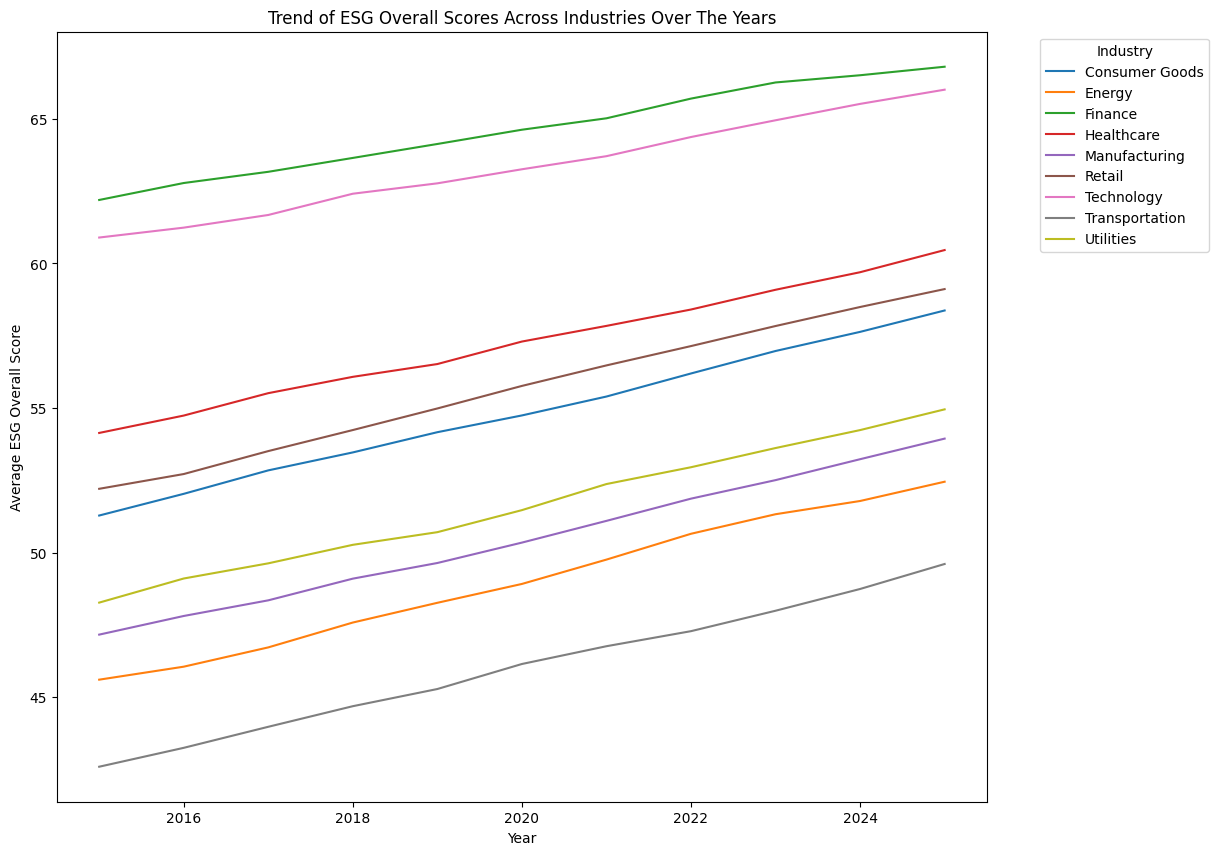

In [19]:
#visualizing the trend of ESG overall scores across industries over the years
plt.figure(figsize = (12, 10))
plt.title("Trend of ESG Overall Scores Across Industries Over The Years")

# Group data by Year and Industry and calculate the mean ESG_Overall score
esg_trend = data.groupby(["Year", "Industry"])["ESG_Overall"].mean().reset_index()

# Plot the trend for each industry
for industry in esg_trend['Industry'].unique():
    industry_data = esg_trend[esg_trend['Industry'] == industry]
    plt.plot(industry_data['Year'], industry_data['ESG_Overall'], label=industry)

plt.xlabel("Year")
plt.ylabel("Average ESG Overall Score")
plt.legend(title="Industry", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(False)
plt.show();

In [20]:
data.columns

Index(['CompanyID', 'CompanyName', 'Industry', 'Region', 'Year', 'Revenue',
       'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall',
       'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions',
       'WaterUsage', 'EnergyConsumption'],
      dtype='object')

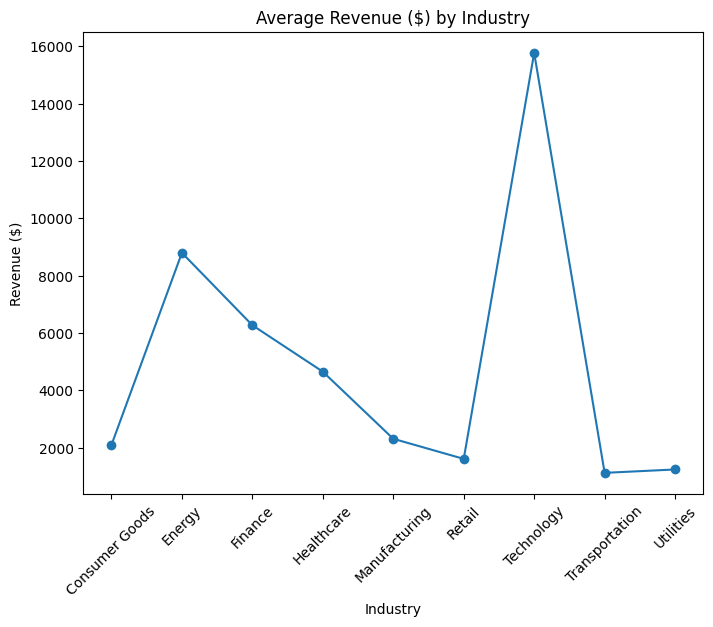

In [21]:
#visualizing the revenue of each industry
plt.figure(figsize = (8,6))
plt.title("Average Revenue ($) by Industry")
plt.plot(data.groupby(["Industry"])["Revenue"].mean(), marker = "o", linestyle = "-")
plt.xlabel("Industry")
plt.xticks(rotation=45)
plt.ylabel("Revenue ($)")
plt.show();

The Technology Industry generates the largest amount of revenue followed by the Energy Industry. In recent times, these industries are fast growing industries with the rise of sustainability through renewable energy and then the rise of AI in the Tech industry, the large revenue could be attributed to that.

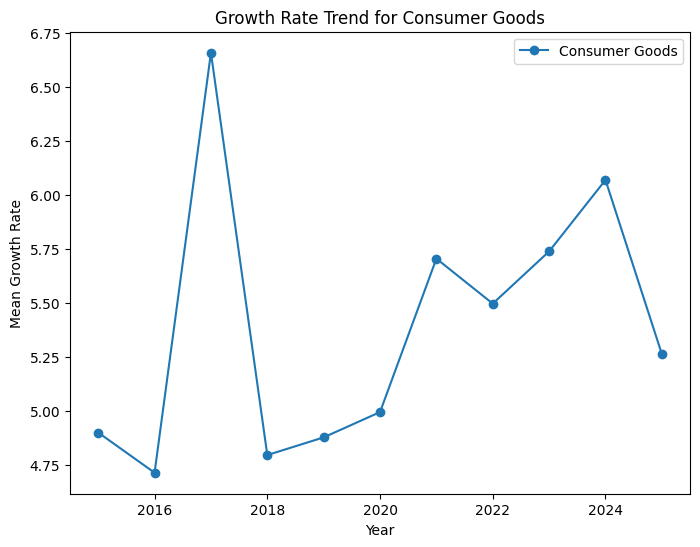

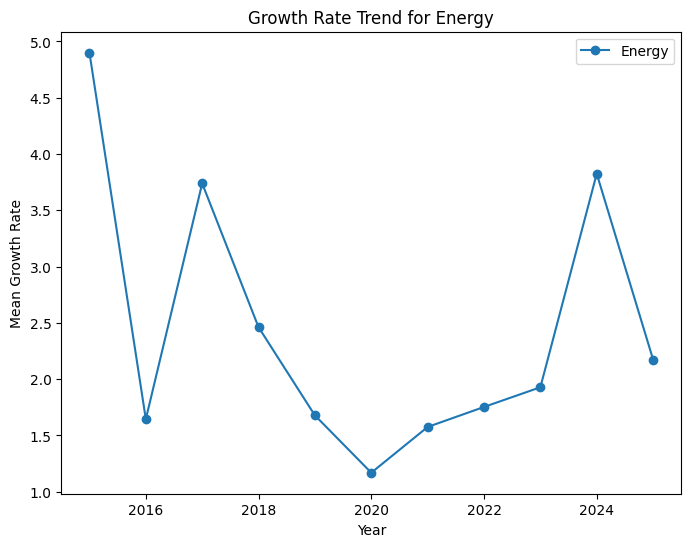

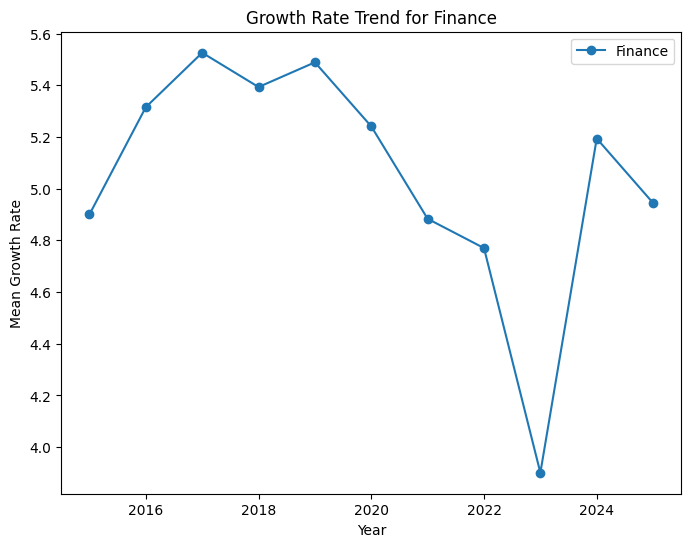

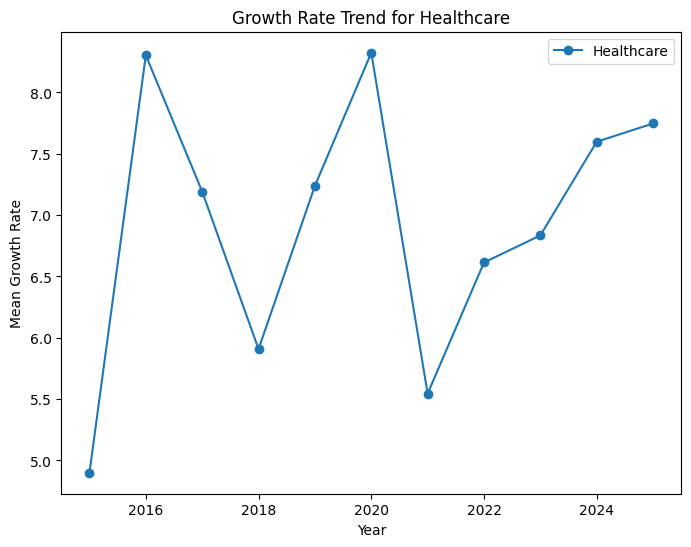

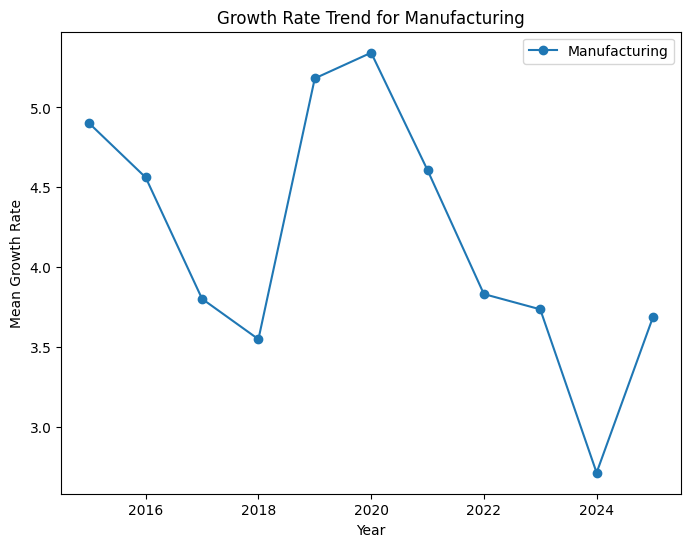

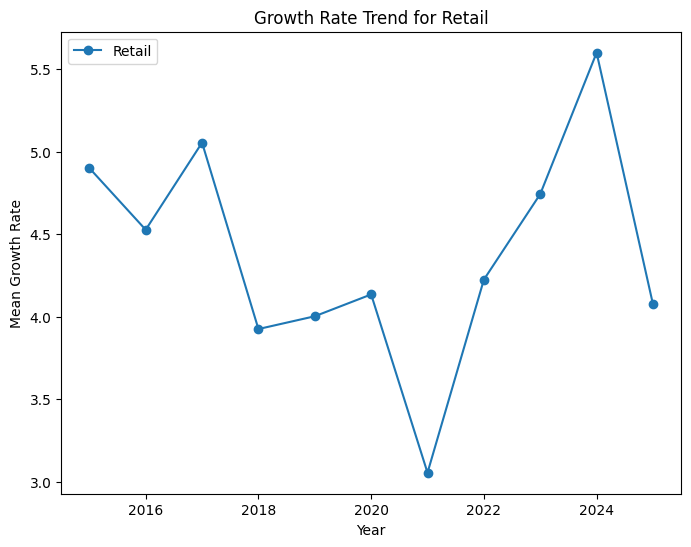

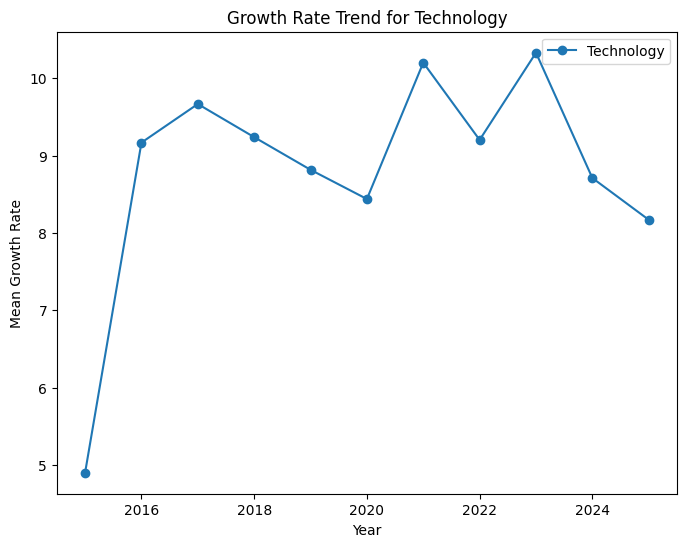

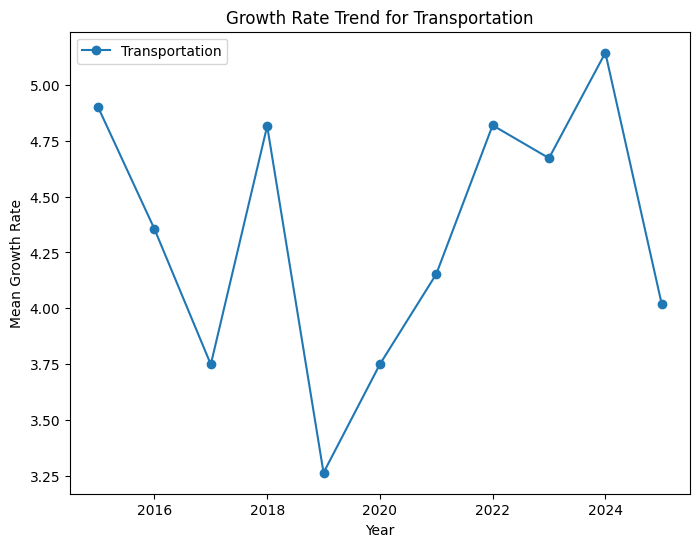

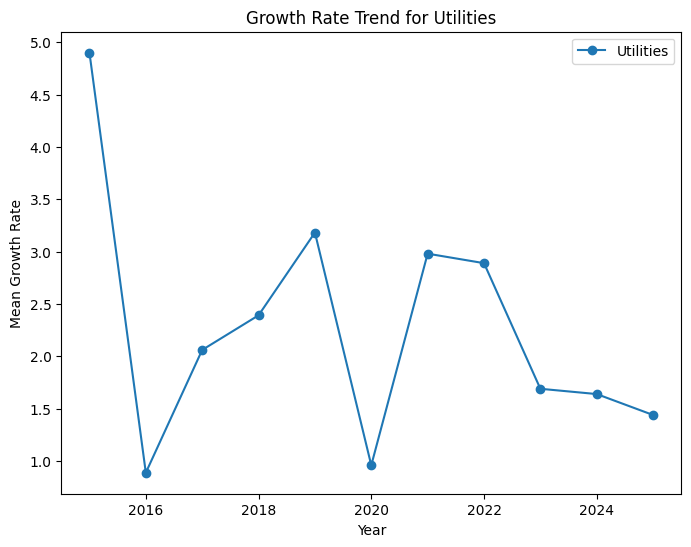

In [22]:
#visualizing the growth rate of industries over the years -> Line graph

# Group data by Year and Industry and calculate the mean GrowthRate
growth = data.groupby(["Year", "Industry"])["GrowthRate"].mean().reset_index()

# Plot the trend for each industry -> Plot it side by side

for industry in growth['Industry'].unique():
    industry_data = growth[growth['Industry'] == industry]
    plt.figure(figsize=(8,6))  # Create a new figure for each industry
    plt.plot(industry_data['Year'], industry_data['GrowthRate'], marker='o', label=industry)
    plt.title(f"Growth Rate Trend for {industry}")
    plt.xlabel("Year")
    plt.ylabel("Mean Growth Rate")
    plt.legend()
    plt.grid(False)
    plt.show();

In [ ]:
#